In [10]:
import Kea
from Kea.utils import plotting
from Kea.simulator import fbm
from Kea.statistics import statistics_base
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive
from Kea.fitting import fit_base

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt

import numpy as np

D = 2
N = 256
L = 2.*np.pi
grid_dims = [N for _ in range(D)]
phys_dims = [L for _ in range(D)]


In [11]:
min, max = -(D+3.), -1.
NUM = 20
alphas = np.linspace(max, min, NUM)
try:
    fields = np.load('data/fields.npy')
except:
    np.random.seed(1234)
    fields = []
    for a in alphas:
        fields.append(fbm.create_fbm(grid_dims, phys_dims, (a,), (1.,)))

In [12]:
try:
    models = np.load('data/models.npy')
except:
    models = []
    for i, a in enumerate(alphas):
        k, _, _ = spectra_base.calculate_integrated_spectrum((fields[i],), spec_type='modal', lenn=phys_dims)
        models.append(fbm.funcs.smooth_pow(k, (a,), (1.,)))

In [13]:
try:
    kfeks = np.load('data/kfeks.npy')
except:    
    kfeks = []
    for f in fields:
        k, fek, _ = spectra_base.calculate_integrated_spectrum((f,), spec_type='modal', lenn=phys_dims)
        kfeks.append((k, fek))

In [14]:
try:
    sfs = np.load('data/sfs.npy')
except:
    sfs = []
    for f in fields:
        lv2 = statfunc_base.get_all_lagvecs([2*n+1 for n in f.shape])
        sf2 = strfn.process_lags(f, f, lv2, periodic=True, lenn=phys_dims, shape=tuple([2*n+1 for n in f.shape]), orders=[2])[0]
        sfs.append(sf2)

In [15]:
try:
    lsf = np.load('data/lsf.npy')
except:
    lsf = []
    for fs in sfs:
        lvm = statfunc_base.get_lagvec_magnitude_array(fs.shape)
        l, sf, _ = statistics_base.bin_data(lvm, fs, mean_func=np.nanmean, cut_excess=True, min_bin=1., ignore_nan=True)
        lsf.append((l, sf))

In [16]:
try:
    k_arevaloz = np.load('data/karevalo.npy')
except:
    k_arevaloz = []
    for i, f in enumerate(fields):
        lags = arevalo_spectra.k_to_discrete_lags(kfeks[i][0], N, L)
        k, fek = arevalo_spectra.modal_spectrum(f, lenn=phys_dims, lags=lags)
        k_arevaloz.append((k, fek))

In [22]:
STRFN_MIN, STRFN_MAX = 10., 50.

sf_avg = {}
for i, ll in enumerate(sfs):
    k, fek = strfn_spectra.omni_spectrum(ll)
    fek = fek/(2.*np.pi*k)
    i_sf_fek = strfn_spectra.interpolate(k, fek, kfeks[i][0])
    idx_min = (np.abs(kfeks[i][0] - STRFN_MIN)).argmin()
    idx_max = (np.abs(kfeks[i][0] - STRFN_MAX)).argmin()

    z, xx, p = fit_base.fit_powerlaw(k, fek, STRFN_MIN, STRFN_MAX)

    sf_avg[-alphas[i]] = (np.nanmean(i_sf_fek[idx_min:idx_max]/models[i][idx_min:idx_max]/(-z[0])), 1.)

sf2_avg = {}
for i, ll in enumerate(sfs):
    k, fek = strfn_spectra.omni_spectrum_2(ll)
    fek = fek/(2.*np.pi*k)
    i_sf_fek = strfn_spectra.interpolate(k, fek, kfeks[i][0])
    idx_min = (np.abs(kfeks[i][0] - STRFN_MIN)).argmin()
    idx_max = (np.abs(kfeks[i][0] - STRFN_MAX)).argmin()
    sf2_avg[-alphas[i]] = (np.nanmean(i_sf_fek[idx_min:idx_max]/models[i][idx_min:idx_max]), 1.)

ek_avg = {}
for i, kfek in enumerate(kfeks):
    k, fek = kfek
    ek_avg[-alphas[i]] = (np.nanmean(fek/models[i]), 1.)

arevalo_avg = {}
for i, kfek in enumerate(k_arevaloz):
    k, fek = kfek
    arevalo_avg[-alphas[i]] = (np.nanmean(fek/models[i]), 1.)

/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 fo

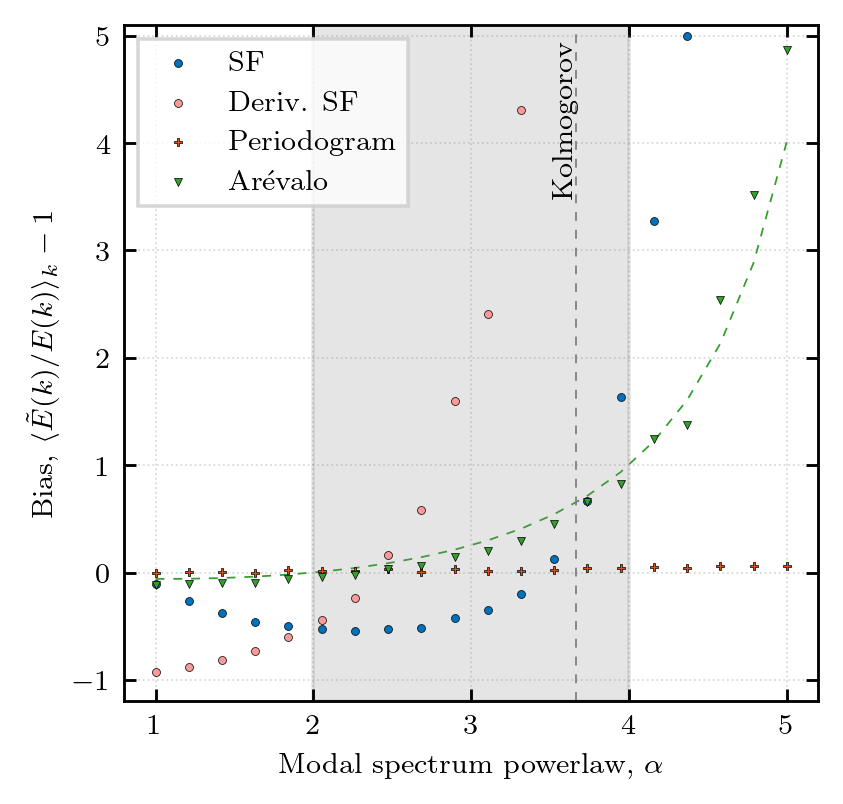

In [23]:
c = plotting.COLOR_CYCLE_6

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

for a in sf_avg.keys():
    ax.scatter(a, sf_avg[a][0] - sf_avg[a][1], marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')

for a in sf2_avg.keys():
    ax.scatter(a, sf2_avg[a][0] - sf2_avg[a][1], marker='o', s=5., color=c[3], zorder=2, linewidth=0.2, edgecolor='black')

for a in ek_avg.keys():
    ax.scatter(a, ek_avg[a][0] - ek_avg[a][1], marker='P', s=5., color=c[1], zorder=2, linewidth=0.2, edgecolor='black')

for a in arevalo_avg.keys():
    ax.scatter(a, arevalo_avg[a][0] - arevalo_avg[a][1], marker='v', s=5., color=c[2], zorder=2, linewidth=0.2, edgecolor='black')

from scipy.special import gamma
aa = -alphas
scaling = 2.**(aa/2.) * gamma(D/2. + 2. - aa/2.) / gamma(D/2. + 2.)
ax.plot(-alphas, scaling - 1., linewidth=0.5, color=c[2], linestyle=(0,(5,5)), zorder=0)

ax.scatter([], [], marker='o', s=5., color=c[0], linewidth=0.2, edgecolor='black', label=r'SF')
ax.scatter([], [], marker='o', s=5., color=c[3], linewidth=0.2, edgecolor='black', label=r'Deriv. SF')
ax.scatter([], [], marker='P', s=5., color=c[1], linewidth=0.2, edgecolor='black', label=r'Periodogram')
ax.scatter([], [], marker='v', s=5., color=c[2], linewidth=0.2, edgecolor='black', label=r'Ar\'evalo')
#ax.plot([], [], color='black', linewidth=0.5, linestyle=(0,(5,5)), label=r'Analytical Ar\'evalo')
ax.legend(fancybox=False, frameon=True, loc='upper left')

ax.axvline(11./3., linestyle=(0, (5, 5)), color='gray', linewidth=0.5, zorder=0)
ax.text(11./3.-0.15, 0.75, r'Kolmogorov', transform=ax.get_xaxis_transform(), rotation=90, color='black')

ax.axvspan(D, D+2., alpha=0.2, color='gray')
#ax.text(2.1, 0.95, r'fBm region', transform=ax.get_xaxis_transform(), color='black')

#ax.set_ylabel('Bias, $\\tilde{\gamma}/\gamma$')
ax.set_ylabel('Bias, $\langle \\tilde{E}(k)/E(k) \\rangle_{k} - 1$')
ax.set_xlabel('Modal spectrum powerlaw, $\\alpha$')

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='x', direction='in')

ax.set_ylim((-1.2, 5.1))

ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

#fig.subplots_adjust(wspace=0.05)
fig.savefig('plots/fbm_spectra_bias.pdf', transparent=True, bbox_inches='tight', pad_inches=0)
fig.savefig('plots/fbm_spectra_bias.png', transparent=True, bbox_inches='tight', pad_inches=0)


In [ ]:
## I SHOULD MAKE A PLOT FOR THE STUCTURE FUNCTION BIAS TO THE STRUCTURE FUNCTION
## THE 'TRUE' STRUCTURE FUNCTION WOULD THEN BE ONE OF THE FORMULAE, PROVIDED BY STUTZKI ET AL 1998.